Deteccion de Bordes

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Suavisado de punto de interez DESENFOQUE A PUNTO DE INTEREZ

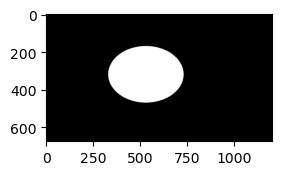

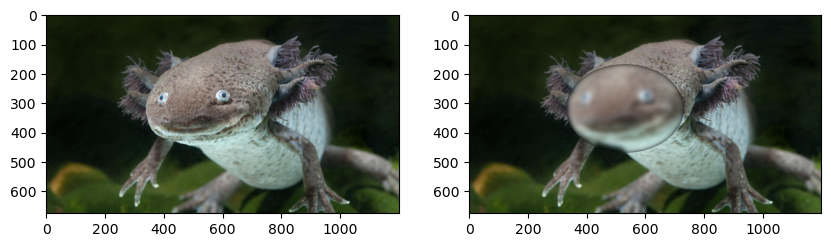

In [12]:
def desenfoqueROI(img, centro, x, y):
  imgCopy = np.copy(img)
  valx,valy = centro
  mediax = x//2
  mediay = y//2
  mask =np.zeros_like(img, dtype=np.uint8)
  cv2.ellipse(mask, (valx,valy),(mediax,mediay),0,0,360,(255,255,255),-1)
  img_mask = cv2.bitwise_and(img,mask)
  desenfoque = cv2.GaussianBlur(img_mask,(49,49),0)
  imgCopy[mask!=0] = desenfoque[mask!=0]
  
  plt.subplot(121)
  plt.imshow(mask)
  return imgCopy
img = cv2.imread('../Img/salamandra.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_des = desenfoqueROI(img_rgb, (530,320), 400,300)
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(img_rgb)
# plt.axis('off')
plt.subplot(122)
plt.imshow(img_des)
# plt.axis('off')

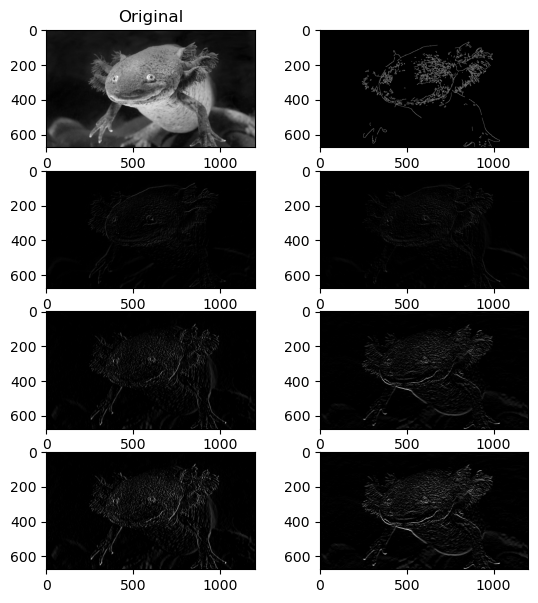

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


img = cv2.imread('../Img/salamandra.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

robertsx= np.array([[-1,0],[0,1]])
robertsy= np.array([[0,-1],[1,0]])

img_robx = cv2.filter2D(img_gray,-1,robertsx)
img_roby = cv2.filter2D(img_gray,-1,robertsy)

rob_mag = np.sqrt(img_robx**2 + img_roby**2)
rob_derec = np.arctan2(img_roby,img_robx)

prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitty = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

img_prewx = cv2.filter2D(img_gray,-1,prewittx)
img_prewy = cv2.filter2D(img_gray,-1,prewitty)

prew_mag = np.sqrt(prewittx**2 + prewitty**2)
prew_dir = np.arctan2(prewitty,prewittx)


sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

sobx_img = cv2.filter2D(img_gray,-1,sobelx)
soby_img = cv2.filter2D(img_gray,-1,sobely)

sobel_grad = np.sqrt(sobelx**2 + sobely**2)
sob_dirc = np.arctan2(sobely, sobelx)

canny = cv2.Canny(img_gray,100,200)

plt.figure(figsize=(10,7))
plt.subplot(4,3,1),
plt.imshow(img_gray,cmap='gray')
plt.title('Original')
plt.subplot(4,3,2),
plt.imshow(canny,cmap='gray')
plt.subplot(4,3,4)
plt.imshow(img_robx,cmap='gray')
plt.subplot(4,3,5)
plt.imshow(img_roby,cmap='gray')
plt.subplot(4,3,7)
plt.imshow(img_prewx,cmap='gray')
plt.subplot(4,3,8)
plt.imshow(img_prewy,cmap='gray')
plt.subplot(4,3,10)
plt.imshow(sobx_img,cmap='gray')
plt.subplot(4,3,11)
plt.imshow(soby_img,cmap='gray')

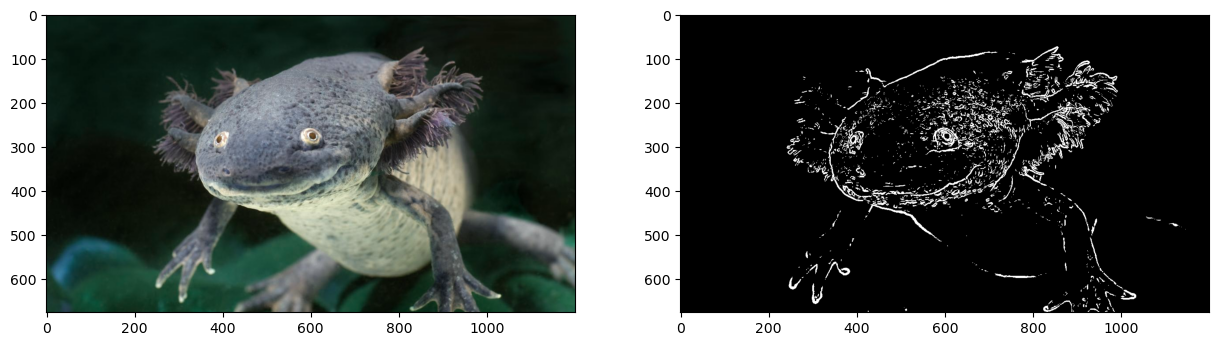

In [22]:
def roberts_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  suavizado = cv2.GaussianBlur(img_gray,(3,3),0)
  kernelx = np.array([[-2,0],[0,2]], dtype=np.float32)
  kernely = np.array([[0,2],[-2,0]], dtype=np.float32)

  robx = cv2.filter2D(suavizado, cv2.CV_16S,kernelx)
  roby = cv2.filter2D(suavizado, cv2.CV_16S,kernely)

  roberts = cv2.addWeighted(np.abs(robx), 0.7, np.abs(roby),0.7,0)

  _,border = cv2.threshold(roberts, 30, 355, cv2.THRESH_BINARY)
  return border

img = cv2.imread('../Img/salamandra.png')
img_rob = roberts_mejorado(img)

plt.figure(figsize=(15,10))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.subplot(122)
plt.imshow(img_rob, cmap='gray')

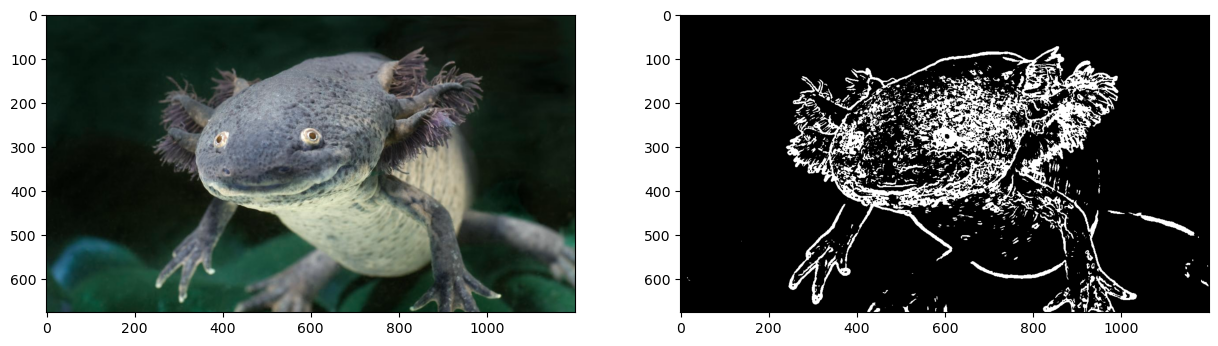

In [30]:
def sobel_mejor(img, tam_kernel=3, umbral=30):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  img_gray = cv2.GaussianBlur(img_gray,(3,3),0)
  sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1,0, ksize=tam_kernel)
  sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0,1, ksize=tam_kernel)

  magnitud = np.sqrt(sobelx**2+sobely**2)

  magnitud = cv2.normalize(magnitud, None, 0,255,cv2.NORM_MINMAX, cv2.CV_8U)
  _,border = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) #se puede agragar OTSU

  kernel_morf = np.ones((2,2), np.uint8)
  border = cv2.morphologyEx(border,cv2.MORPH_CLOSE, kernel_morf)
  return border

img = cv2.imread('../Img/salamandra.png')
img_rob = sobel_mejor(img)

plt.figure(figsize=(15,10))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.subplot(122)
plt.imshow(img_rob, cmap='gray')

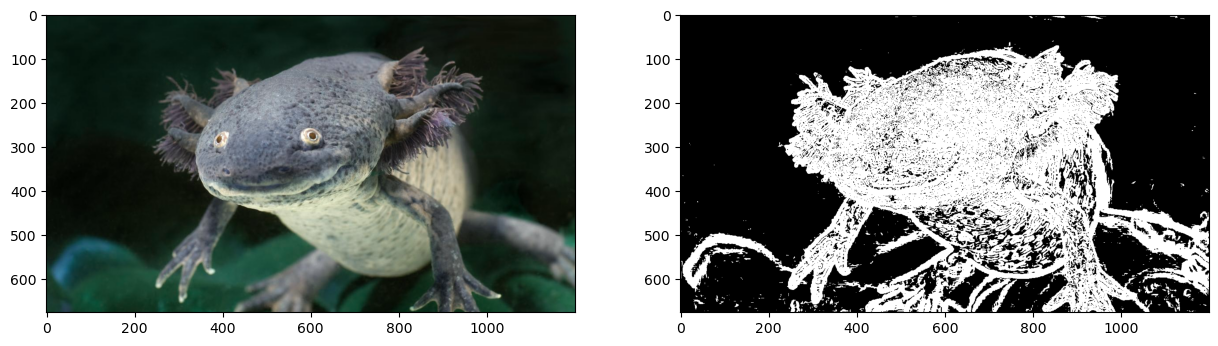

In [36]:
def prewitt_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  img_gray = cv2.GaussianBlur(img_gray, (3,3),0)
  prewittx = np.array([[3,0,-3],[3,0,-3],[3,0,-3]], dtype=np.float32)
  prewitty = np.array([[3,3,3],[0,0,0],[-3,-3,-3]], dtype=np.float32)
  x= cv2.filter2D(img_gray, cv2.CV_64F, prewittx)
  y= cv2.filter2D(img_gray, cv2.CV_64F, prewitty)
  
  magnitud = np.sqrt(x**2 + y**2)
  _,border = cv2.threshold(magnitud, 30,255, cv2.THRESH_BINARY)
  return border



img = cv2.imread('../Img/salamandra.png')
img_rob = prewitt_mejorado(img)

plt.figure(figsize=(15,10))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.subplot(122)
plt.imshow(img_rob, cmap='gray')


In [41]:
#funcion roberts feo
def roberts_feo(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertsx= np.array([[-1,0],[0,1]])
    robertsy= np.array([[0,-1],[1,0]])

    robx = cv2.filter2D(img_gray,-1,robertsx)
    roby = cv2.filter2D(img_gray,-1,robertsy)

    return [robx, roby]


In [44]:
def sobel_feo(img):
  sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
  sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

  sobx_img = cv2.filter2D(img_gray,-1,sobelx)
  soby_img = cv2.filter2D(img_gray,-1,sobely)

  magnitud = np.sqrt(sobelx**2 + sobely**2)
  sob_dirc = np.arctan2(sobely, sobelx)

  return [sobx_img, soby_img]




In [45]:
def prewitt_feo(img):
  prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
  prewitty = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
  img_prewx = cv2.filter2D(img_gray,-1,prewittx)
  img_prewy = cv2.filter2D(img_gray,-1,prewitty)
  prew_mag = np.sqrt(prewittx**2 + prewitty**2)
  prew_dir = np.arctan2(prewitty,prewittx)

  return [img_prewx, img_prewy]

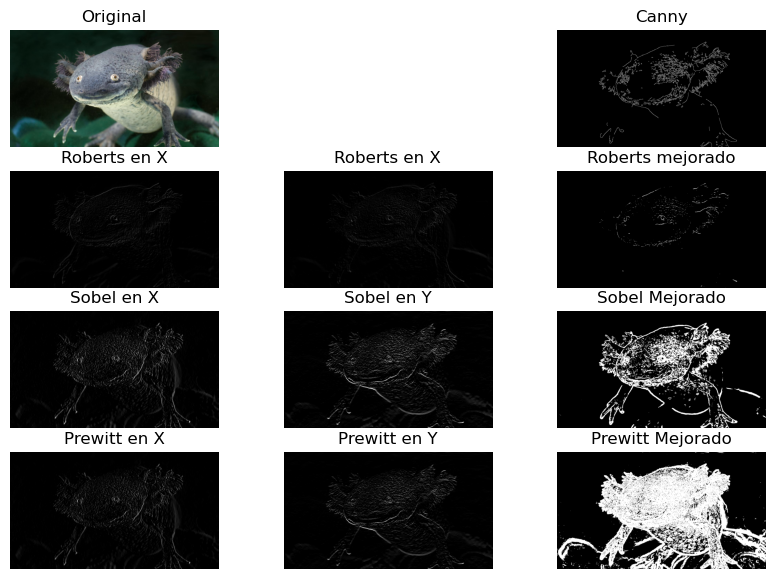

In [52]:
img = cv2.imread('../Img/salamandra.png')


imgs_rober = roberts_feo(img)
img_rob_m = roberts_mejorado(img)

imgs_sobels = sobel_feo(img)
img_sobel_m = sobel_mejor(img)

imgs_prews = prewitt_feo(img)
img_prew_m = prewitt_mejorado(img)



plt.figure(figsize=(10,7))
plt.subplot(4,3,1)
plt.axis('off')
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.subplot(4,3,3),
plt.title('Canny')
plt.axis('off')
plt.imshow(canny,cmap='gray')
plt.subplot(4,3,4)
plt.title('Roberts en X')
plt.axis('off')
plt.imshow(imgs_rober[0], cmap='gray')
plt.subplot(4,3,5)
plt.title('Roberts en X')
plt.axis('off')
plt.imshow(imgs_rober[1], cmap='gray')
plt.subplot(4,3,6)
plt.title('Roberts mejorado')
plt.axis('off')
plt.imshow(img_rob, cmap='gray')
plt.subplot(4,3,7)
plt.title('Sobel en X')
plt.axis('off')
plt.imshow(imgs_sobels[0], cmap='gray')
plt.subplot(4,3,8)
plt.title('Sobel en Y')
plt.axis('off')
plt.imshow(imgs_sobels[1], cmap='gray')
plt.subplot(4,3,9)
plt.title('Sobel Mejorado')
plt.axis('off')
plt.imshow(img_sobel_m, cmap='gray')
plt.subplot(4,3,10)
plt.title('Prewitt en X')
plt.axis('off')
plt.imshow(imgs_prews[0], cmap='gray')
plt.subplot(4,3,11)
plt.title('Prewitt en Y')
plt.axis('off')
plt.imshow(imgs_prews[1], cmap='gray')
plt.subplot(4,3,12)
plt.title('Prewitt Mejorado')
plt.axis('off')
plt.imshow(img_prew_m, cmap='gray')


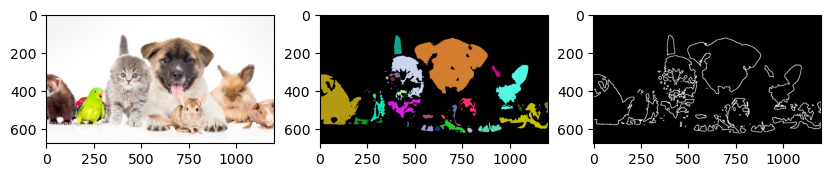

In [10]:
path='../Img/mascotas.jpg'

imagen= cv2.imread(path)

gray= cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(7,7),0)
_,binarizado=cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#regiones

cant,region=cv2.connectedComponents(binarizado)
colores=np.random.randint(0,255,size=(cant,3),dtype=np.uint8)
colores[0]=[0,0,0]
color_reg=colores[region]

#fronteras
contorno,_=cv2.findContours(binarizado,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
lineas=cv2.drawContours(np.zeros_like(gray),contorno,-1,255,2)

plt.figure(figsize=(10,5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.imshow(color_reg)

plt.subplot(133)
plt.imshow(lineas,cmap='gray')

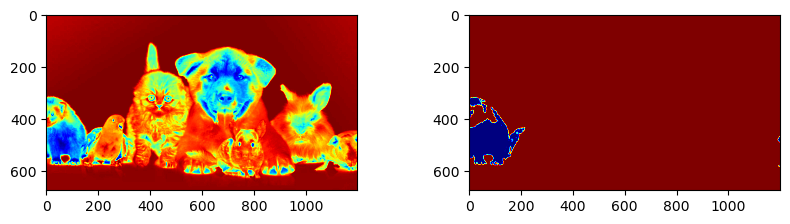

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def etiquetar(img):
    #umbralizado binario
    _,imgBIN=cv2.threshold(img,127,255,cv2.THRESH_BINARY)
    #encontrar los contornos
    contorno,_=cv2.findContours(imgBIN,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    img_etiquetada=np.zeros_like(img,dtype=np.uint8)
    for i ,contornoss in enumerate(contorno):
        cv2.drawContours(img_etiquetada,[contornoss],-1,(i+1),-1)
    return img_etiquetada

path='../Img/mascotas.jpg'
imagen=cv2.imread(path,0)
imagen_eti=etiquetar(imagen)
plt.figure(figsize=(10,5))

plt.subplot(221)
plt.imshow(imagen,cmap='jet')

plt.subplot(222)
plt.imshow(imagen_eti,cmap='jet')

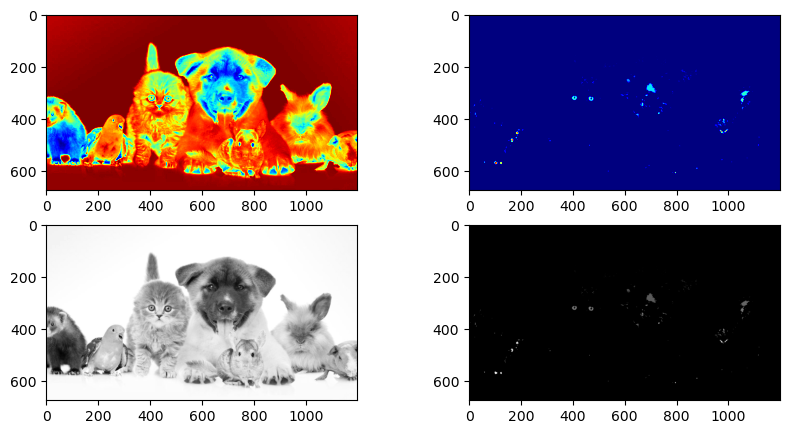

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img_gray=cv2.imread(path,0)
_,imgbin=cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)
img_etiq=measure.label(imgbin,connectivity=1)
plt.figure(figsize=(10,5))

plt.subplot(221)
plt.imshow(img_gray,cmap='jet')

plt.subplot(222)
plt.imshow(img_etiq,cmap='jet')

plt.subplot(223)
plt.imshow(img_gray,cmap='gray')

plt.subplot(224)
plt.imshow(img_etiq,cmap='gray')

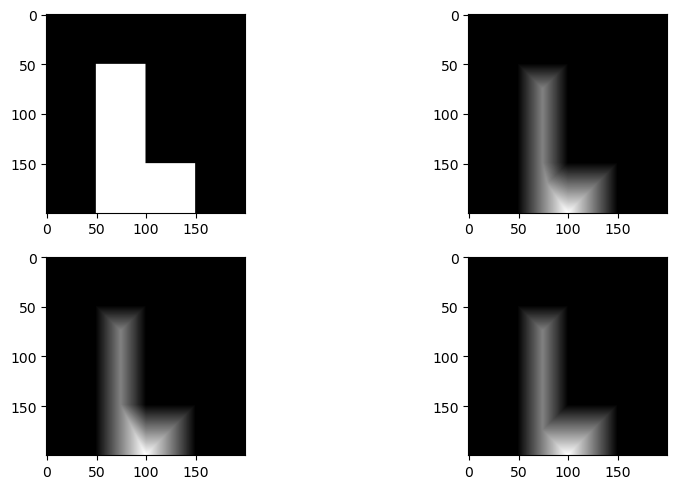

In [11]:
img=np.zeros((200,200),dtype=np.uint8)
img[50:150,50:100]=1
img[150:200,50:150]=1

def distancia(img_binarizada):
    invertir=1-img_binarizada

    #eucladiana
    dist_eucli=cv2.distanceTransform(img_binarizada,cv2.DIST_L2,3)
    #CITYBLOCK
    dist_city= cv2.distanceTransform(img_binarizada,cv2.DIST_L1,3)
    #CHEASSBOAR
    dist_chess= cv2.distanceTransform(img_binarizada,cv2.DIST_C,3)
    return dist_eucli,dist_city,dist_chess

eucl,city,chess=distancia(img)

def normalizar(dis):
    return cv2.normalize(dis,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)

normecl= normalizar(eucl) 
normcity= normalizar(city)
normchess =normalizar(chess)

plt.figure(figsize=(10,5))

plt.subplot(221)
plt.imshow(img,cmap='gray')

plt.subplot(222)
plt.imshow(normecl,cmap='gray')

plt.subplot(223)
plt.imshow(normcity,cmap='gray')

plt.subplot(224)
plt.imshow(normchess,cmap='gray')

plt.tight_layout()
plt.show()

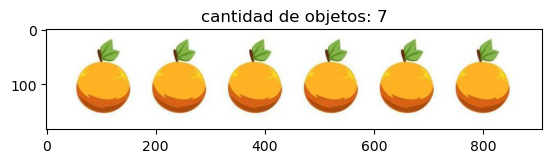

In [27]:
#conda activate "entorno_pdi"
#conda install scikit-image
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure

def contar(imagen):
    gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    _,bianrizar=cv2.threshold(gray,214,255,cv2.THRESH_BINARY)
    etiquetar=measure.label(bianrizar,connectivity=2)#conectividad con 4 == 2 y conectividad de 8 == 1
    num=np.max(etiquetar)
    return num

imagen=cv2.imread('../Img/frutas.jpg')
contarr=contar(imagen)

plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'cantidad de objetos: {contarr}')
plt.show()

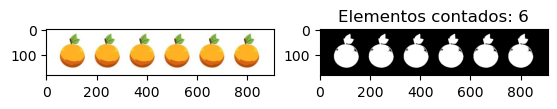

In [14]:

def conteo(img):
    img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binaria=cv2.threshold(img_gray,200,202,cv2.THRESH_BINARY_INV)
    borde,_=cv2.findContours(binaria,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cont=len(borde)
    return cont,binaria
    
imagen=cv2.imread('../Img/frutas.jpg')
img_cont,bin=conteo(imagen)

plt.figure(figsize=(10,5))

plt.subplot(231)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(232)
plt.title(f'Elementos contados: {img_cont}')
plt.imshow(bin,cmap='gray')
plt.show()

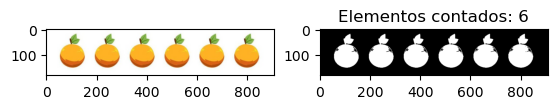

In [9]:
from skimage import measure

def conunt (img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _,binarizada = cv2.threshold(img_gray, 193,255,cv2.THRESH_BINARY_INV)
  contorno = measure.label(binarizada, connectivity=2)
  cont = np.max(contorno)
  return cont, binarizada

img = cv2.imread('../Img/frutas.jpg')
cont, bin = conunt(img)

plt.figure(figsize=(10,5))

plt.subplot(231)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.subplot(232)
plt.title(f'Elementos contados: {cont}')
plt.imshow(bin,cmap='gray')
plt.show()